In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning problem 3

### Data Preprocessing

In [56]:
# Load the dataset and look at the first 10 rows
df = pd.read_csv('Rental_Price_Prediction.csv')
df.head(10)

,Property_Area,Bedrooms,Bathrooms,Property_Age,Proximity_to_City_Center,Monthly_Rent
0,NaN,3,2,49,17.34,534.21
1,2290.29,1,1,45,10.90,1189.16
2,2355.08,4,1,25,5.46,2856.12
3,4344.88,4,2,33,1.53,2716.47
4,4229.60,1,2,10,3.70,666.39
5,3584.85,3,1,28,14.21,874.42
6,628.93,1,1,6,7.14,2885.31
7,1472.76,3,1,45,12.53,967.77
8,692.18,3,2,31,11.87,845.37
9,3317.78,4,2,49,5.54,1719.73


In [57]:
# See if all fields are numbers
df.dtypes

Property_Area               float64
Bedrooms                      int64
Bathrooms                     int64
Property_Age                  int64
Proximity_to_City_Center    float64
Monthly_Rent                float64
dtype: object

In [58]:
# Look at the scale of the data
df.describe()

,Property_Area,Bedrooms,Bathrooms,Property_Age,Proximity_to_City_Center,Monthly_Rent
count,9000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2740.935092,2.483600,1.50590,25.019000,10.440625,1757.878039
std,1302.231047,1.119311,0.49999,14.130414,5.486271,725.776514
min,500.180000,1.000000,1.00000,1.000000,1.000000,500.410000
25%,1588.522500,1.000000,1.00000,13.000000,5.660000,1134.017500
50%,2743.105000,2.000000,2.00000,25.000000,10.450000,1760.530000
75%,3869.452500,3.000000,2.00000,37.000000,15.120000,2388.457500
max,4998.810000,4.000000,2.00000,49.000000,20.000000,2999.640000


#### Handle missing values

In [59]:
# Print total number of null values per field
df.isnull().sum()

Property_Area               1000
Bedrooms                       0
Bathrooms                      0
Property_Age                   0
Proximity_to_City_Center       0
Monthly_Rent                   0
dtype: int64

In [60]:
# Impute the missing values with the mean
df['Property_Area'] = df['Property_Area'].fillna(df['Property_Area'].mean())

In [61]:
# Check if there are any duplicated rows
df.duplicated().sum()

0

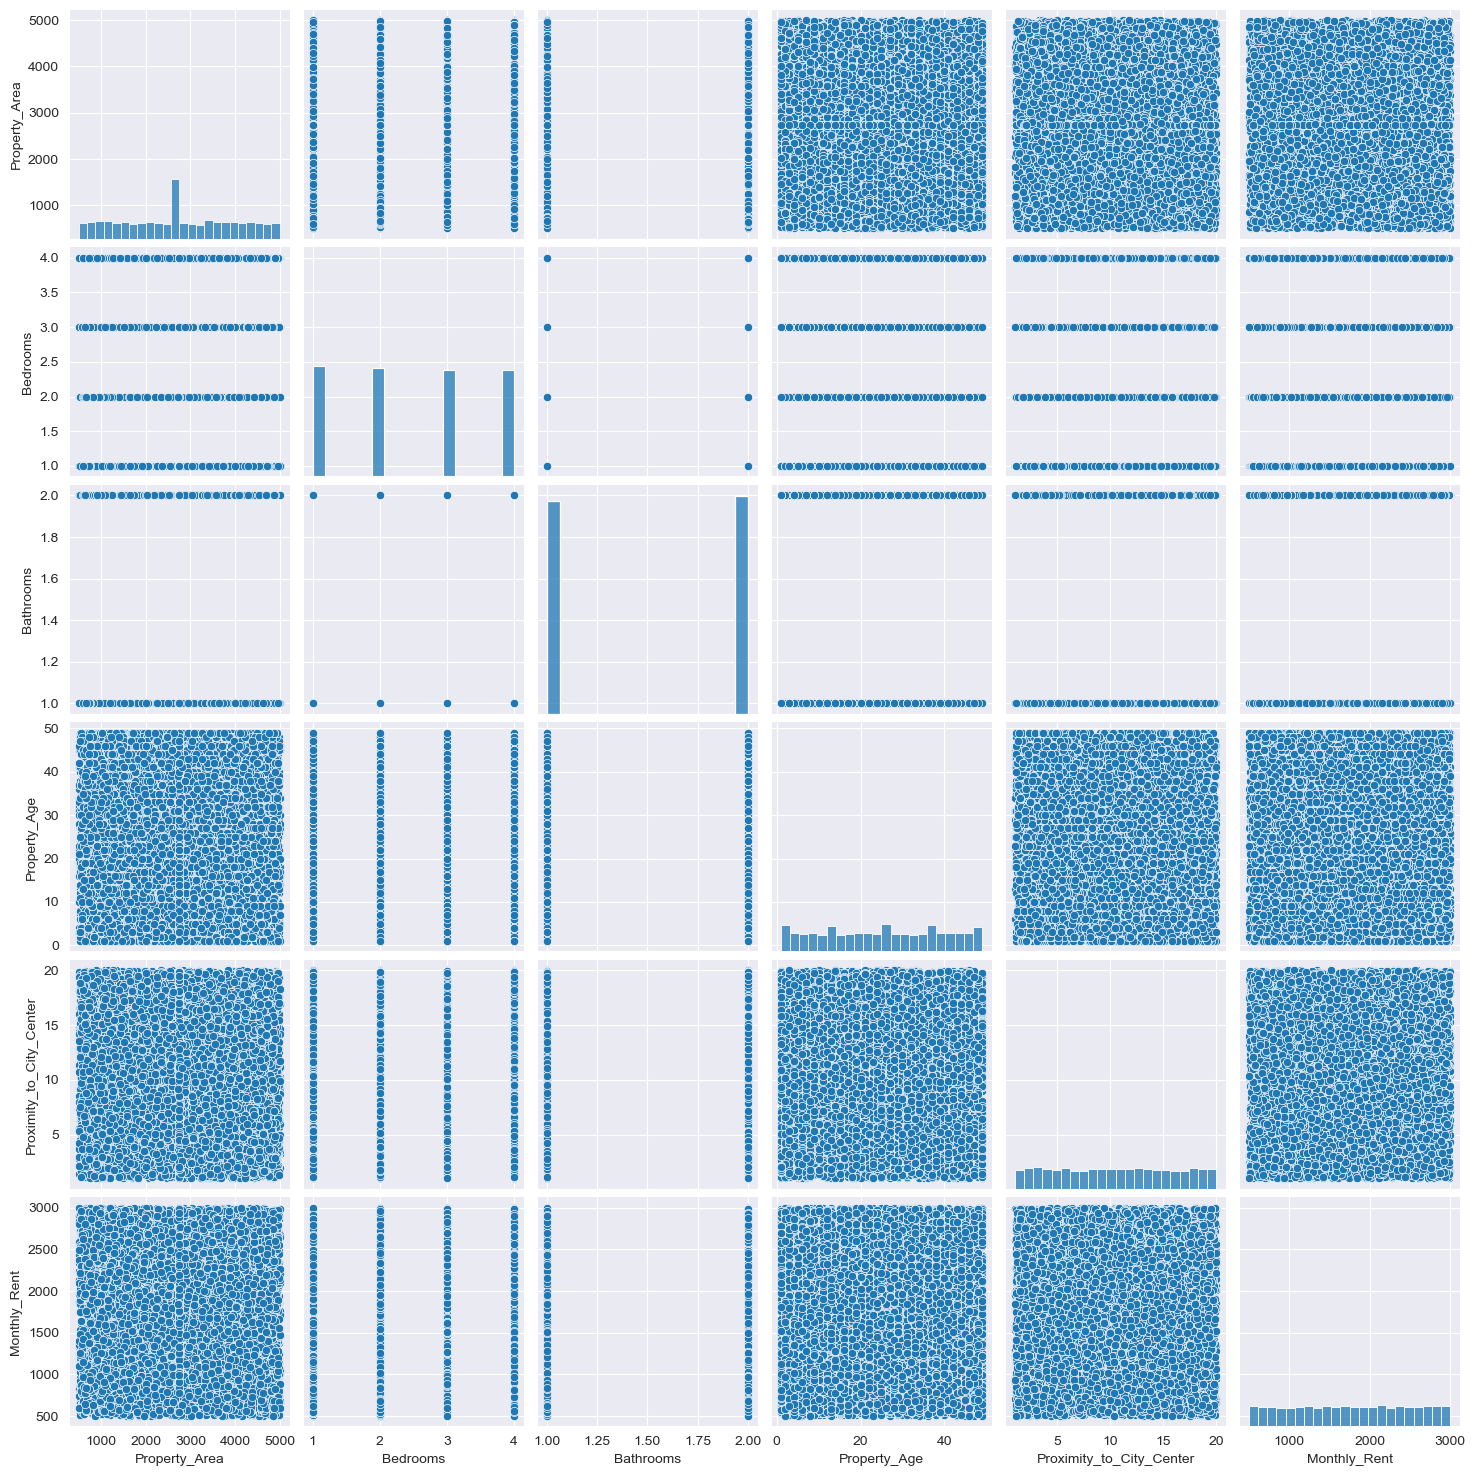

In [62]:
# See how the different fields are distributed
sns.pairplot(df)

<Axes: >

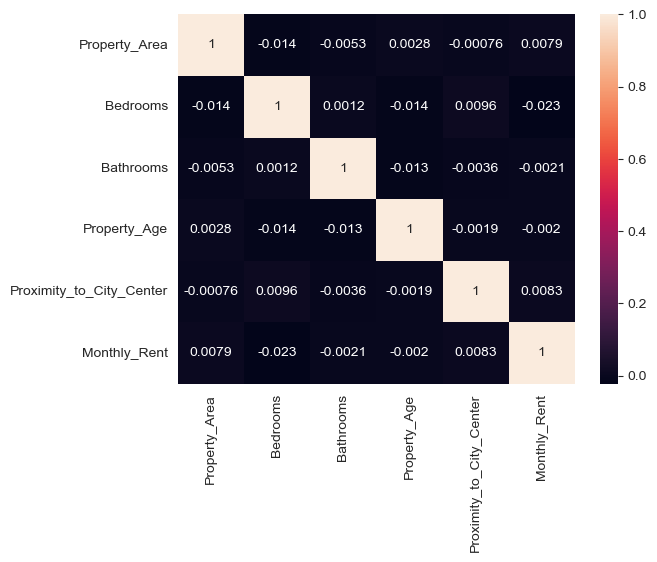

In [63]:
# See correlation between each field
sns.heatmap(df.corr(), annot=True)

#### Split data on input and output variables


In [64]:
# X are inputs and y are output
X = df.drop('Monthly_Rent', axis=1)
y = df['Monthly_Rent']
print(X.shape, y.shape)

(10000, 5) (10000,)


#### Split the dataset to train, validation and test sets

In [65]:
from sklearn.model_selection import train_test_split

# train+val and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# train+val set split to train and val sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=2)

In [66]:
# Print shapes to see that dimensionality is correct
(X_train.shape, y_train.shape), (X_val.shape, y_val.shape), (X_test.shape, y_test.shape)

(((6000, 5), (6000,)), ((2000, 5), (2000,)), ((2000, 5), (2000,)))

#### Normalize the training and validation data

In [67]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Model building

#### Designing the model

In [68]:
# Import necessary libraries for creating the model
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

2.17.0
3.6.0


In [69]:
# Import the classes we need from the above libraries
from keras.models import Sequential
from keras.layers import InputLayer, Dense

In [70]:
# Defining all the layer parameters
input_neurons = X_train.shape[1]
hidden_layer_1_neurons = 64
hidden_layer_2_neurons = 32
output_neurons = 1

In [71]:
# Defining the model and giving it layers
model = Sequential()

model.add(InputLayer(shape= (input_neurons,)))
model.add(Dense(hidden_layer_1_neurons, activation='relu'))
model.add(Dense(hidden_layer_2_neurons, activation='relu'))
model.add(Dense(output_neurons, activation='linear'))

In [72]:
# Summary of the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Compiling the model
from keras.optimizers import Adam
model.compile(loss='mse', optimizer=Adam(learning_rate=0.0001 ), metrics=['mae'])

#### Training the model

In [74]:
# Train the model on X_train and y_train, using X_val and y_val as validation
model_results = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3691357.7500 - mae: 1780.3718 - val_loss: 3593349.0000 - val_mae: 1750.0861
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - loss: 3662621.2500 - mae: 1774.7150 - val_loss: 3585927.7500 - val_mae: 1747.9614
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - loss: 3642137.0000 - mae: 1769.7238 - val_loss: 3571936.2500 - val_mae: 1743.9448
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - loss: 3560856.0000 - mae: 1745.9310 - val_loss: 3548172.0000 - val_mae: 1737.0996
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - loss: 3504876.7500 - mae: 1727.1267 - val_loss: 3512235.2500 - val_mae: 1726.6952
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 3591121.2500 - mae: 1751.3021 - val_loss: 3463450.5000 - val_mae: 1712.4669
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 3467592.5000 - mae: 1716.8408 - val_loss: 3401648.7500 - val_mae: 1694.2611
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━

#### Evaluating the model on the test data

In [75]:
# Print out final MSE loss score
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"MSE: {scores[0]:.2f}")

MSE: 659983.25


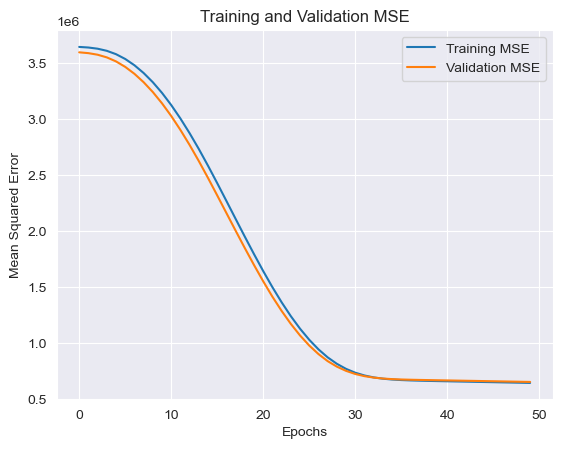

In [76]:
# Plot the Mean Squared Error over Epochs
plt.plot(model_results.history['loss'], label='Training MSE')
plt.plot(model_results.history['val_loss'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation MSE')
plt.legend()
plt.show()

In [77]:
# See the final loss to see if the model is over- or under-fitting
print("Final Training Loss: ", model_results.history['loss'][-1])
print("Final Validation Loss: ", model_results.history['val_loss'][-1])

Final Training Loss:  643843.8125
Final Validation Loss:  652767.875


### Analysis

#### Plot distribution of predicted vs. actual values from output field

In [78]:
# Predict values from the model
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [79]:
# See the range of the true and predicted values
print("True values range: ", np.min(y_test), "to", np.max(y_test))
print("Predicted values range: ", np.min(y_pred), "to", np.max(y_pred))

True values range:  500.53 to 2999.43
Predicted values range:  668.6313 to 2741.4082


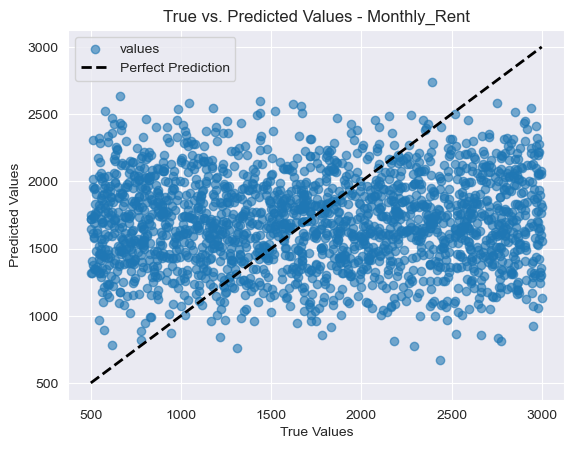

In [80]:
# Plot how close the model is from perfect prediction
plt.scatter(y_test, y_pred, alpha=0.6, label='values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values - Monthly_Rent')
plt.legend()
plt.show()

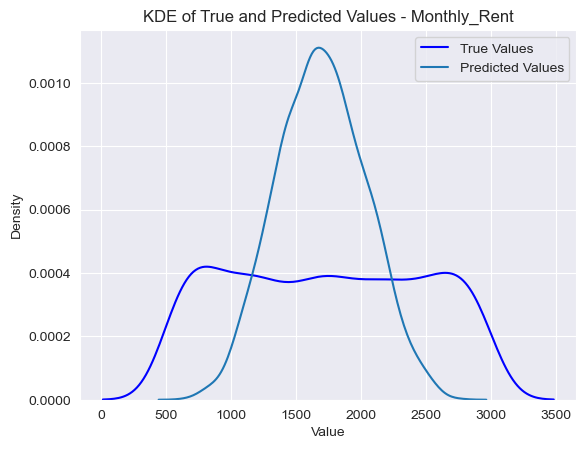

In [81]:
# Plot the distribution of predicted and true values
sns.kdeplot(y_test, label='True Values', color='blue')
sns.kdeplot(y_pred, label='Predicted Values', color='orange')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('KDE of True and Predicted Values - Monthly_Rent')
plt.legend()
plt.show()